# Test & performance report (robust comparison)

A single, self-contained run that answers: **does the workflow work, and does it help?**

1. **Automated test suite** — the fast `pytest` suite (unit + integration).
2. **Does the loop help?** — a **robust** closed-loop comparison vs a matched space-filling
   design: **15 seeds, full acquisition settings**, final-regret significance test, and a
   regret-vs-effort trajectory.
3. **Does it know when it is not learning?** — the null-response sanity check.
4. **Are the error bars honest?** — the two calibration checks on a real campaign.
5. **Timing** — how long each part took.

**How to read this report.** Each section states *why it matters*, *how to read it*, and a
*pass condition*. Run it top to bottom; every number is generated live, so it is yours, not a
baked-in example.

> **⏱ Runtime.** Section 2 is the heavyweight: 15 seeds × 5 rounds with **full** acquisition
> settings (`num_restarts=20, raw_samples=512`) plus per-round incumbent evaluations. Expect it
> to run for a substantial time (roughly 1–3 hours on a laptop). To do a quick smoke pass first,
> drop `SEEDS_COMPARISON` to `range(3)` in the setup cell. Sections 3–4 stay light (few seeds)
> on purpose — they are already clear at low cost.

**Reproducibility.** Every seed is fixed, so results are deterministic — rerunning reproduces
them exactly (only the section 5 timings drift).

## Setup

In [9]:
import os, subprocess, sys, time, warnings
from pathlib import Path

warnings.simplefilter("ignore")

# Locate the repo root, then make both `check` (at the root) and the `adoe`
# package (under src/) importable -- so this runs even without `pip install -e .`.
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "run this notebook from the repo or its notebooks/ folder"
SRC = ROOT / "src"
for _path in (ROOT, SRC):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import check  # shipped validation script; reused for the quick sections 3-4
from adoe.campaign import _find_incumbent, compute_status, confirm, initial_design, propose
from adoe.model import fit_model
from adoe.report import status_page   # note: forces matplotlib's Agg backend on import
from adoe.simulate import FermentationSimulator, NullSimulator

# adoe.report selects Agg; restore inline so figures render in the notebook.
%matplotlib inline

# ---- knobs ----
INITIAL_UNITS = 16
ROUND_UNITS = 6
ROUNDS = 5                       # 16 + 4*6 = 40 units per campaign
FULL = dict(num_restarts=20, raw_samples=512)   # full acquisition search effort

SEEDS_COMPARISON = range(15)     # section 2 (robust; the expensive one)
SEEDS_QUICK = range(3)           # sections 3-4 (already clear at low cost)

timings = {}
print("full acquisition settings:", FULL)
print(f"section 2 seeds: {len(list(SEEDS_COMPARISON))} | loop: {INITIAL_UNITS} + {ROUNDS-1}x{ROUND_UNITS}")

full acquisition settings: {'num_restarts': 20, 'raw_samples': 512}
section 2 seeds: 15 | loop: 16 + 4x6


## 1. Automated test suite

**Why it matters.** The unit and integration tests pin the encode/decode round trip, the
write-once ledger, the log-transform handling, and that the model beats an intercept-only
baseline. If any break, no performance number below can be trusted.

**How to read it.** One summary line straight from `pytest`. The two end-to-end checks are
marked `slow` and deselected here because sections 2–4 exercise that path directly.

**Pass condition:** green `N passed` with exit code 0.

In [10]:
t0 = time.time()
# Put src/ on PYTHONPATH so the pytest subprocess resolves `adoe` without an install.
env = dict(os.environ, PYTHONPATH=str(SRC) + os.pathsep + os.environ.get("PYTHONPATH", ""))
proc = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "--no-header"],
    cwd=ROOT, capture_output=True, text=True, env=env,
)
timings["1. pytest suite"] = time.time() - t0
print(proc.stdout.splitlines()[-1] if proc.stdout else proc.stderr[-400:])
print("exit code:", proc.returncode, "->", "PASS" if proc.returncode == 0 else "FAIL")

17 passed, 2 deselected, 50 warnings in 36.37s
exit code: 0 -> PASS


## 2. Does the loop help?  (robust comparison)

**Why it matters.** The central claim: adaptively choosing conditions finds a better recipe than
spreading experiments evenly. If a well-balanced space-filling design does just as well, the GP
and acquisition loop are dead weight. A cheap 3-seed check can look either way by luck, so this
section is deliberately heavy.

**How to read it.** For **15 seeds**, at **full acquisition settings**, we run the adaptive loop
and a **matched space-filling design of the same size**, measuring **regret at the model
incumbent** (the gap to the true optimum at the recipe the workflow would actually recommend;
lower is better). We report three things:

- **final-regret comparison** across seeds, with a **Wilcoxon signed-rank test** (paired, one
  sided) so "adaptive is lower" becomes a significance statement rather than an eyeball call;
- a **paired plot** (each seed's space-filling → adaptive regret);
- a **regret-vs-effort trajectory** (median and inter-quartile band across seeds), which is where
  a sequential method should separate from space-filling as the budget grows;
- an **observed-performance-vs-effort** panel — mean and best-so-far *observed* yield (with noise)
  as the budget grows. This is the bench-facing view; note it is not directly comparable to the
  regret panels, which are measured noise-free at the model incumbent.

**Pass condition:** adaptive median regret below space-filling, ideally with Wilcoxon **p < 0.05**
and a trajectory whose adaptive band sits below the space-filling band at the larger budgets; the
best-observed-yield curve should likewise climb faster/higher for adaptive. If the margin is small
and p is not significant, say so — that is the honest reading.

In [11]:
# --- Section 2 helpers: full-settings regret + observed mean/best trajectories ---
from scipy.stats import wilcoxon

def incumbent_regret(ledger, sim, domain, seed):
    model = fit_model(ledger, domain, seed=seed)
    inc, _ = _find_incumbent(model, domain, block=0, **FULL)   # full search for the recommendation
    frame = pd.DataFrame([inc]); frame[domain.block_column] = 0
    true_here = float(sim.evaluate(frame, np.random.default_rng(0))["y_true"].iloc[0])
    _, optimum = sim.true_optimum()
    return optimum - true_here

def observed_stats(ledger, domain):
    """Mean and best-so-far observed yield among successful units."""
    y = pd.to_numeric(ledger.loc[ledger["failed"] == False, "y"], errors="coerce").dropna()
    if len(y) == 0:
        return np.nan, np.nan
    best = y.max() if domain.target.direction == "maximize" else y.min()
    return float(y.mean()), float(best)

def adaptive_trajectory(sim, domain, seed):
    rng = np.random.default_rng(seed)
    ledger = check._evaluate_into(initial_design(domain, n_conditions=INITIAL_UNITS, seed=seed), sim, domain, rng)
    traj = [(len(ledger), incumbent_regret(ledger, sim, domain, seed))]
    obs = [(len(ledger), *observed_stats(ledger, domain))]
    for _ in range(ROUNDS - 1):
        prop = propose(ledger, domain, n_conditions=ROUND_UNITS, r=1, seed=seed, **FULL)
        ledger = pd.concat([ledger, check._evaluate_into(prop, sim, domain, rng)], ignore_index=True)
        traj.append((len(ledger), incumbent_regret(ledger, sim, domain, seed)))
        obs.append((len(ledger), *observed_stats(ledger, domain)))
    return traj, obs

def spacefill_trajectory(sim, domain, seed, sizes):
    traj, obs = [], []
    for n in sizes:
        rng = np.random.default_rng(seed + 9973 + n)
        led = check._evaluate_into(initial_design(domain, n_conditions=n, seed=seed + 9973 + n), sim, domain, rng)
        traj.append((n, incumbent_regret(led, sim, domain, seed)))
        obs.append((n, *observed_stats(led, domain)))
    return traj, obs

t0 = time.time()
sim = FermentationSimulator(); domain = sim.domain
adaptive_traj, sf_traj = {}, {}
adaptive_obs, sf_obs = {}, {}          # observed mean/best trajectories, for the plot below
for seed in SEEDS_COMPARISON:
    at, ao = adaptive_trajectory(sim, domain, seed)
    adaptive_traj[seed], adaptive_obs[seed] = at, ao
    st, so = spacefill_trajectory(sim, domain, seed, [n for n, _ in at])
    sf_traj[seed], sf_obs[seed] = st, so
    print(f"seed {seed:2d}: final regret  adaptive {at[-1][1]:6.2f}  |  space-filling {sf_traj[seed][-1][1]:6.2f}")
timings["2. loop-helps (15 seeds, full)"] = time.time() - t0
print("done")

seed  0: final regret  adaptive   3.26  |  space-filling   3.25
seed  1: final regret  adaptive   1.28  |  space-filling   4.21
seed  2: final regret  adaptive   5.84  |  space-filling  12.81
seed  3: final regret  adaptive   1.84  |  space-filling   2.14
seed  4: final regret  adaptive   8.22  |  space-filling   8.84
seed  5: final regret  adaptive   4.44  |  space-filling   6.73
seed  6: final regret  adaptive   5.15  |  space-filling  10.99
seed  7: final regret  adaptive   2.40  |  space-filling  11.53
seed  8: final regret  adaptive   7.65  |  space-filling   5.44
seed  9: final regret  adaptive   5.94  |  space-filling   5.13
seed 10: final regret  adaptive   1.58  |  space-filling   8.26
seed 11: final regret  adaptive   2.23  |  space-filling   1.68
seed 12: final regret  adaptive   1.27  |  space-filling   4.08
seed 13: final regret  adaptive   2.72  |  space-filling   3.16
seed 14: final regret  adaptive   2.46  |  space-filling  13.20
done


adaptive median regret       = 2.72 g/L
space-filling median regret  = 5.44 g/L
adaptive wins                = 11/15 seeds
median improvement (sf-adap) = 2.29 g/L
Wilcoxon signed-rank (adaptive < space-filling): p = 0.00754
VERDICT: PASS -- significant (p<0.05)


,seed,adaptive,space_filling,improvement (sf - adaptive)
0,0,3.263720,3.249828,-0.013893
1,1,1.280650,4.211333,2.930683
2,2,5.837122,12.807599,6.970477
3,3,1.843238,2.135739,0.292500
4,4,8.218749,8.839753,0.621003
5,5,4.437052,6.730554,2.293501
6,6,5.145065,10.990324,5.845259
7,7,2.402362,11.533070,9.130708
8,8,7.645226,5.444047,-2.201179
9,9,5.937461,5.125655,-0.811806


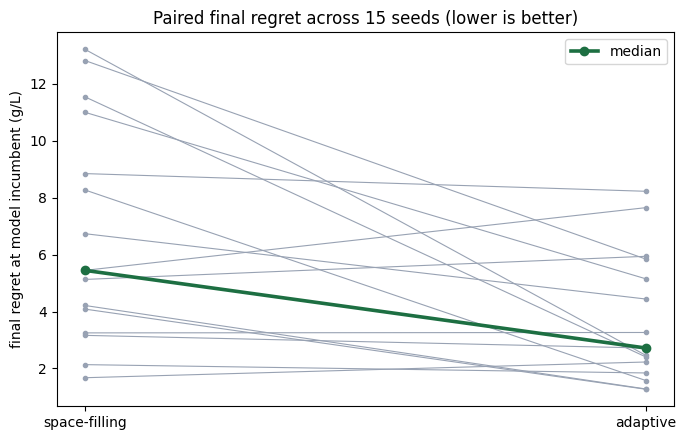

In [12]:
# Final-regret comparison + paired significance test.
seeds = list(SEEDS_COMPARISON)
final = pd.DataFrame({
    "seed": seeds,
    "adaptive": [adaptive_traj[s][-1][1] for s in seeds],
    "space_filling": [sf_traj[s][-1][1] for s in seeds],
})
final["improvement (sf - adaptive)"] = final["space_filling"] - final["adaptive"]
wins = int((final["adaptive"] < final["space_filling"]).sum())
med_a, med_s = final["adaptive"].median(), final["space_filling"].median()
try:
    _, p = wilcoxon(final["adaptive"], final["space_filling"], alternative="less")
except ValueError:
    p = float("nan")   # e.g. all-equal differences

print(f"adaptive median regret       = {med_a:.3g} g/L")
print(f"space-filling median regret  = {med_s:.3g} g/L")
print(f"adaptive wins                = {wins}/{len(final)} seeds")
print(f"median improvement (sf-adap) = {final['improvement (sf - adaptive)'].median():.3g} g/L")
print(f"Wilcoxon signed-rank (adaptive < space-filling): p = {p:.3g}")
sig = "significant (p<0.05)" if p < 0.05 else "NOT significant (p>=0.05)"
print("VERDICT:", "PASS" if (med_a < med_s and p < 0.05) else "WEAK/INCONCLUSIVE", f"-- {sig}")

fig, ax = plt.subplots(figsize=(7, 4.5))
for _, r in final.iterrows():
    ax.plot([0, 1], [r["space_filling"], r["adaptive"]], color="#98A2B3", lw=0.8, marker="o", ms=3)
ax.plot([0, 1], [med_s, med_a], color="#1D6F42", lw=2.6, marker="o", label="median")
ax.set_xticks([0, 1]); ax.set_xticklabels(["space-filling", "adaptive"])
ax.set_ylabel("final regret at model incumbent (g/L)")
ax.set_title(f"Paired final regret across {len(final)} seeds (lower is better)")
ax.legend(); fig.tight_layout()
final

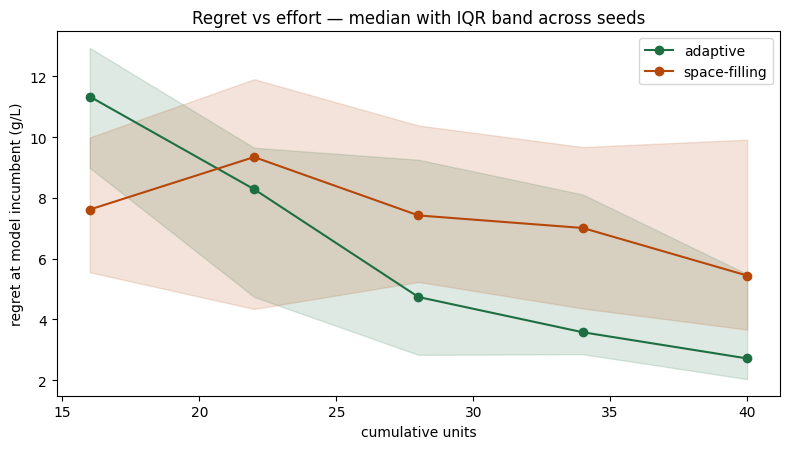

In [13]:
# Regret vs effort: median and inter-quartile band across seeds.
sizes = [n for n, _ in adaptive_traj[seeds[0]]]
A = np.array([[r for _, r in adaptive_traj[s]] for s in seeds])
S = np.array([[r for _, r in sf_traj[s]] for s in seeds])
fig, ax = plt.subplots(figsize=(8, 4.6))
for label, M, c in [("adaptive", A, "#1D6F42"), ("space-filling", S, "#B54708")]:
    ax.plot(sizes, np.median(M, axis=0), marker="o", color=c, label=label)
    ax.fill_between(sizes, np.percentile(M, 25, axis=0), np.percentile(M, 75, axis=0), color=c, alpha=0.15)
ax.set_xlabel("cumulative units"); ax.set_ylabel("regret at model incumbent (g/L)")
ax.set_title("Regret vs effort — median with IQR band across seeds")
ax.legend(); fig.tight_layout(); plt.show()

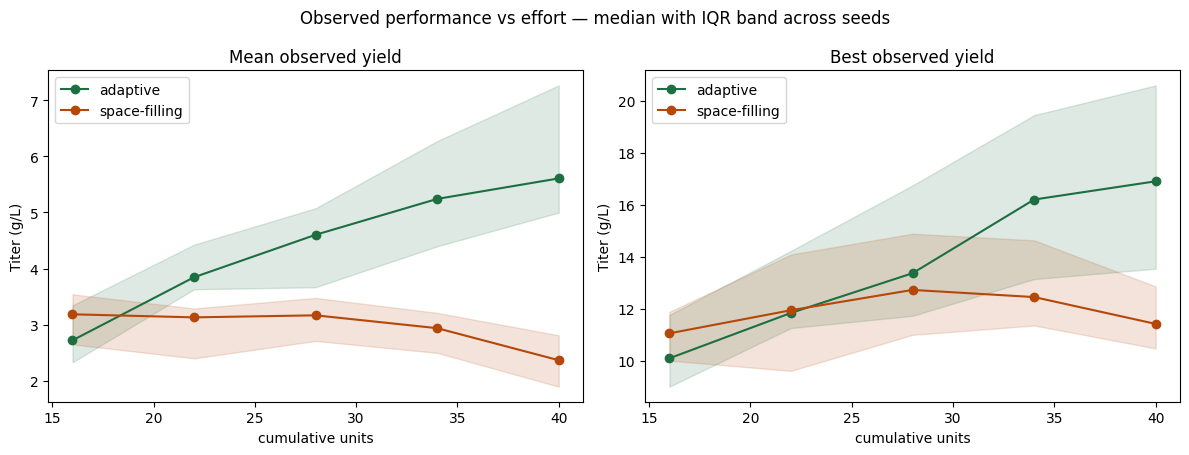

In [14]:
# Observed performance vs effort: mean and best-so-far yield (median + IQR across seeds).
# Unlike the regret panels above, this is the *observed* yield (includes noise), not the
# noise-free value at the model incumbent -- so read the two as complementary.
obs_sizes = [n for n, _, _ in adaptive_obs[seeds[0]]]

def _stack(obs, idx):                          # idx 1 = within-campaign mean, 2 = best-so-far
    return np.array([[step[idx] for step in obs[s]] for s in seeds])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)
for ax, idx, title in [(axes[0], 1, "Mean observed yield"), (axes[1], 2, "Best observed yield")]:
    for label, obs, c in [("adaptive", adaptive_obs, "#1D6F42"), ("space-filling", sf_obs, "#B54708")]:
        M = _stack(obs, idx)
        ax.plot(obs_sizes, np.median(M, axis=0), marker="o", color=c, label=label)
        ax.fill_between(obs_sizes, np.percentile(M, 25, axis=0), np.percentile(M, 75, axis=0), color=c, alpha=0.15)
    ax.set_xlabel("cumulative units")
    ax.set_ylabel(f"{domain.target.name} ({domain.target.unit})")
    ax.set_title(title); ax.legend()
fig.suptitle("Observed performance vs effort — median with IQR band across seeds")
fig.tight_layout(); plt.show()

## 3. Does it know when it is not learning?

**Why it matters.** Pointed at pure noise, the workflow must **not** invent a signal. This is the
honesty half of the promise. (Kept light — few seeds, default settings — because it is already
clear at low cost and doesn't depend on acquisition search quality.)

**How to read it.** The same loop against a **null** response (independent of every input); we
look at **prospective RMSE ÷ baseline SD** (the baseline is guessing the average). A ratio near
or **above 1** is correct — no signal extracted from noise. We also check the apparent
improvement over the control stays small.

**Pass condition:** median ratio above ~0.85 and a small apparent improvement.

In [15]:
t0 = time.time()
null_sim = NullSimulator(); null_domain = null_sim.domain
rows = []
for seed in SEEDS_QUICK:
    ledger = check._run_adaptive(null_sim, null_domain, seed)   # light settings from check.py
    numbers = compute_status(ledger, null_domain)
    rows.append({"seed": seed,
                 "RMSE / baseline": float(numbers["learning_rmse"]) / float(numbers["baseline_sd"]),
                 "|improvement| %": abs(float(numbers["improvement_pct"]))})
null = pd.DataFrame(rows)
timings["3. null-response check"] = time.time() - t0
ratio = null["RMSE / baseline"].median()
print(f"median prospective RMSE / baseline SD = {ratio:.3g}  (>=~1 is correct)")
print(f"median apparent improvement vs control = {null['|improvement| %'].median():.1f}%")
print("VERDICT:", "PASS" if ratio > 0.85 else "FAIL")
null

median prospective RMSE / baseline SD = 1.26  (>=~1 is correct)
median apparent improvement vs control = 4.3%
VERDICT: PASS


,seed,RMSE / baseline,|improvement| %
0,0,1.261044,7.541342
1,1,1.259469,2.620715
2,2,1.830798,4.300318


## 4. Are the error bars honest?

**Why it matters.** The recipe card's 95% interval is only trustworthy if the model's uncertainty
is calibrated. (A single-campaign snapshot; calibration varies run to run, so read it as one
example, not a population claim.)

**How to read it.** One real campaign plus a replicated `confirm` round, then `status()`:
**check A** (prospective RMSE vs guess-the-mean; lower = learning) and **check B**
(`rms_z` target ≈ 1, 95% coverage target ≥ 90%). `rms_z` uses RMS, so it catches systematic bias.

**Pass condition:** check A well below baseline (clear learning). For check B, `rms_z` ≲ 1.25 and
coverage ≥ 0.90 means trustworthy intervals; higher `rms_z` / lower coverage means the workflow is
honestly flagging that early intervals are optimistic — treat them as rough (expected with only
~30–60 units, per the README).

best recipe predicted typical yield = 18.8 g/L  (+97% vs control)
repeat-to-repeat noise  = +/-13%   (rough replicates to detect a 10% gain: 8)
is it learning?   RMSE 0.920  vs  baseline 1.442
honest bars?      rms_z 1.44  |  95% coverage 91%


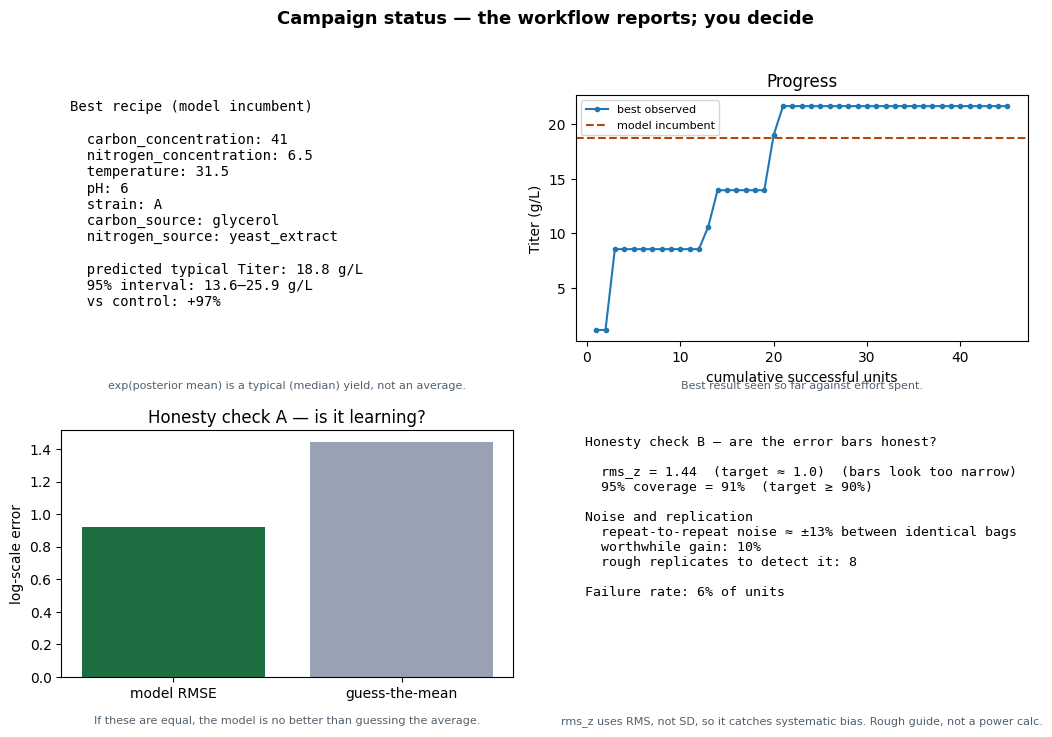

In [16]:
t0 = time.time()
demo_ledger = check._run_adaptive(sim, domain, seed=0)
conf = confirm(demo_ledger, domain, r=3, seed=0, num_restarts=check.NUM_RESTARTS, raw_samples=check.RAW_SAMPLES)
conf = check._evaluate_into(conf, sim, domain, np.random.default_rng(101))
demo_ledger = pd.concat([demo_ledger, conf], ignore_index=True)
numbers = compute_status(demo_ledger, domain)
timings["4. status page"] = time.time() - t0

def _f(v, spec, missing="n/a"):
    return format(v, spec) if v is not None else missing

print(f"best recipe predicted typical yield = {numbers['best_recipe']['predicted_median']:.3g} "
      f"{domain.target.unit}  ({_f(numbers['improvement_pct'], '+.0f')}% vs control)")
print(f"repeat-to-repeat noise  = +/-{_f(numbers['noise_pct'], '.0f')}%   "
      f"(rough replicates to detect a {numbers['delta_pct']:g}% gain: {numbers['replicates_guide']})")
print(f"is it learning?   RMSE {_f(numbers['learning_rmse'], '.3f')}  vs  baseline {_f(numbers['baseline_sd'], '.3f')}")
print(f"honest bars?      rms_z {_f(numbers['rms_z'], '.2f')}  |  95% coverage {_f(numbers['coverage'], '.0%')}")
import matplotlib.pyplot as plt
fig = status_page(demo_ledger, domain, numbers)
plt.close(fig)   # avoid a duplicate render from the inline backend
fig

## 5. Timing

In [17]:
timing = pd.Series(timings).round(1)
timing.loc["TOTAL"] = round(timing.sum(), 1)
print(timing.to_string())

1. pytest suite                     38.0
2. loop-helps (15 seeds, full)    3817.3
3. null-response check             162.0
4. status page                      43.3
TOTAL                             4060.6


## Summary

Fill this in from the sections above once you have run them:

| Question | What to check | Pass condition |
|---|---|---|
| Do the tests pass? | section 1 | `N passed`, exit 0 |
| Does the loop help? | section 2 | adaptive median regret < space-filling **and** Wilcoxon p < 0.05 |
| Does it avoid false learning? | section 3 | median RMSE/baseline ≳ 1 on pure noise |
| Are the 95% intervals honest? | section 4 | check A clearly learning; check B calibrated, or honestly flagged as rough |